<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Multivariate" data-toc-modified-id="Multivariate-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Multivariate</a></span></li><li><span><a href="#Univariate" data-toc-modified-id="Univariate-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Univariate</a></span></li></ul></div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import ccf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
wdf = pd.read_csv('waterlevel_58236010.csv')
rdf = pd.read_csv('rainfall_564863.csv')

print(wdf)
print(rdf)

                       Timestamp  Value
0      2023-01-01 00:00:00+00:00  0.292
1      2023-01-01 00:15:00+00:00  0.291
2      2023-01-01 00:30:00+00:00  0.291
3      2023-01-01 00:45:00+00:00  0.290
4      2023-01-01 01:00:00+00:00  0.289
...                          ...    ...
70171  2024-12-31 22:45:00+00:00  1.040
70172  2024-12-31 23:00:00+00:00  1.027
70173  2024-12-31 23:15:00+00:00  1.015
70174  2024-12-31 23:30:00+00:00  1.000
70175  2024-12-31 23:45:00+00:00  0.987

[70176 rows x 2 columns]
                       Timestamp  Value
0      2023-01-01 00:00:00+00:00    0.0
1      2023-01-01 00:15:00+00:00    0.0
2      2023-01-01 00:30:00+00:00    0.0
3      2023-01-01 00:45:00+00:00    0.0
4      2023-01-01 01:00:00+00:00    0.0
...                          ...    ...
70171  2024-12-31 22:45:00+00:00    0.0
70172  2024-12-31 23:00:00+00:00    0.0
70173  2024-12-31 23:15:00+00:00    0.0
70174  2024-12-31 23:30:00+00:00    0.0
70175  2024-12-31 23:45:00+00:00    0.0

[70176 rows x

In [3]:
wdf['Timestamp'] = pd.to_datetime(wdf['Timestamp']).dt.tz_localize(None)
rdf['Timestamp'] = pd.to_datetime(rdf['Timestamp']).dt.tz_localize(None)

print(wdf)
print(rdf)

                Timestamp  Value
0     2023-01-01 00:00:00  0.292
1     2023-01-01 00:15:00  0.291
2     2023-01-01 00:30:00  0.291
3     2023-01-01 00:45:00  0.290
4     2023-01-01 01:00:00  0.289
...                   ...    ...
70171 2024-12-31 22:45:00  1.040
70172 2024-12-31 23:00:00  1.027
70173 2024-12-31 23:15:00  1.015
70174 2024-12-31 23:30:00  1.000
70175 2024-12-31 23:45:00  0.987

[70176 rows x 2 columns]
                Timestamp  Value
0     2023-01-01 00:00:00    0.0
1     2023-01-01 00:15:00    0.0
2     2023-01-01 00:30:00    0.0
3     2023-01-01 00:45:00    0.0
4     2023-01-01 01:00:00    0.0
...                   ...    ...
70171 2024-12-31 22:45:00    0.0
70172 2024-12-31 23:00:00    0.0
70173 2024-12-31 23:15:00    0.0
70174 2024-12-31 23:30:00    0.0
70175 2024-12-31 23:45:00    0.0

[70176 rows x 2 columns]


In [4]:
# Data count
print(f"Initial Water Level data points: {len(wdf)}")
print(f"Initial Rainfall data points: {len(rdf)}")

Initial Water Level data points: 70176
Initial Rainfall data points: 70176


In [5]:
# Check for missing values
print("Water level missing values:\n", wdf.isnull().sum())
print("\nRainfall missing values:\n", rdf.isnull().sum())

Water level missing values:
 Timestamp    0
Value        0
dtype: int64

Rainfall missing values:
 Timestamp    0
Value        0
dtype: int64


In [6]:
# Check for duplicates
wdf = wdf.drop_duplicates(subset=['Timestamp']).dropna()
rdf = rdf.drop_duplicates(subset=['Timestamp']).dropna()

print(f"Water Level after cleaning: {len(wdf)}")
print(f"Rainfall after cleaning: {len(rdf)}")

Water Level after cleaning: 70176
Rainfall after cleaning: 70176


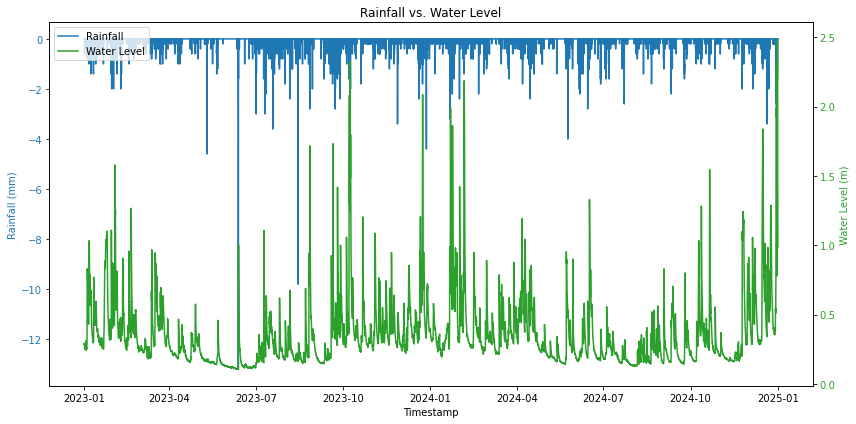

In [7]:
# Visualisation
plt.figure(figsize=(12, 6))

# Create primary axis
ax1 = plt.gca()
color = 'tab:blue'
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Rainfall (mm)', color=color)
ax1.plot(rdf['Timestamp'], -rdf['Value'], color=color, label='Rainfall')
ax1.tick_params(axis='y', labelcolor=color)

# Create secondary axis
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Water Level (m)', color=color)
ax2.plot(wdf['Timestamp'], wdf['Value'], color=color, label='Water Level')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('Rainfall vs. Water Level')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [8]:
# Merge datasets
merged = pd.merge_asof(wdf.sort_values('Timestamp'), 
                      rdf.sort_values('Timestamp'), 
                      on='Timestamp',
                      direction='nearest',
                      tolerance=pd.Timedelta('15min'))
merged = merged.rename(columns={'Value_x': 'WaterLevel', 'Value_y': 'Rainfall'})
print(merged)

                Timestamp  WaterLevel  Rainfall
0     2023-01-01 00:00:00       0.292       0.0
1     2023-01-01 00:15:00       0.291       0.0
2     2023-01-01 00:30:00       0.291       0.0
3     2023-01-01 00:45:00       0.290       0.0
4     2023-01-01 01:00:00       0.289       0.0
...                   ...         ...       ...
70171 2024-12-31 22:45:00       1.040       0.0
70172 2024-12-31 23:00:00       1.027       0.0
70173 2024-12-31 23:15:00       1.015       0.0
70174 2024-12-31 23:30:00       1.000       0.0
70175 2024-12-31 23:45:00       0.987       0.0

[70176 rows x 3 columns]


In [9]:
# Correlation
corr, p_value = pearsonr(merged['WaterLevel'], merged['Rainfall'])
print(f"Pearson correlation: {corr:.3f} (p-value: {p_value:.3f})")

if abs(corr) < 0.3:
    print("Low correlation - suggesting time lag effects")

Pearson correlation: 0.172 (p-value: 0.000)
Low correlation - suggesting time lag effects


In [10]:
x = merged['Rainfall'].values
y = merged['WaterLevel'].values

# Normalise
x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

# Full cross-correlation
corrs = np.correlate(y, x, mode='full')
lags = np.arange(-len(x)+1, len(x))

# Find lag with maximum correlation
best_lag = lags[np.argmax(corrs)]
print(f"Max correlation at lag = {best_lag} samples")

# Convert lag to time
time_step = pd.to_timedelta('15min')
time_lag = best_lag * time_step
print(f"Time lag = {time_lag}")

Max correlation at lag = 31 samples
Time lag = 0 days 07:45:00


water level time series is most strongly correlated with rainfall that happened 31 time steps earlier <br>
31 samples × 15 minutes = 465 minutes = 7 hours 45 minutes <br>
Rainfall now will most strongly influence the water level ~7 hours 45 minutes later

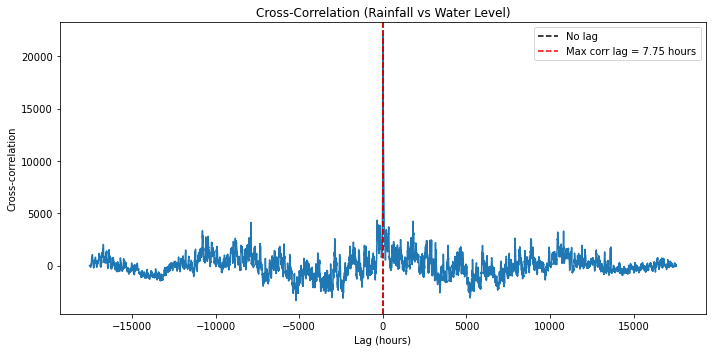

In [11]:
lags_hours = lags * (15/60)  # 15 minutes per sample
plt.figure(figsize=(10,5))
plt.plot(lags_hours, corrs)
plt.axvline(x=0, color='k', linestyle='--', label='No lag')
plt.axvline(x=best_lag*(15/60), color='r', linestyle='--', 
            label=f'Max corr lag = {best_lag*(15/60):.2f} hours')
plt.xlabel('Lag (hours)')
plt.ylabel('Cross-correlation')
plt.title('Cross-Correlation (Rainfall vs Water Level)')
plt.legend()
plt.tight_layout()
plt.show()

lags runs from -(N-1) to +(N-1) where N is the number of samples in the series.

If you then multiply by 15 minutes (0.25 hours per sample), the range becomes <br>
lag_min = -(N-1) * 0.25 hours <br>
lag_max = +(N-1) * 0.25 hours <br>

N ≈ (2 years × 365 days × 24 hours × 4 samples/hour) ≈ 70,000 samples <br>
lag_max_hours ≈ (70,000 × 0.25) ≈ 17,500 hours <br>
It simply means the cross-correlation was computed over the full length of the dataset, but most of that range is not physically meaningful.

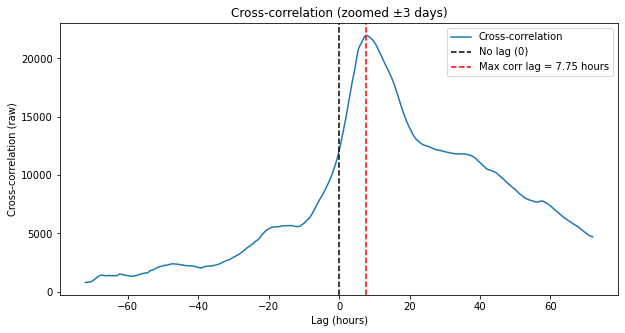

In [12]:
# Suppose you only care about ±3 days = 3*24 hours
max_hours = 3*24
mask = (lags_hours >= -max_hours) & (lags_hours <= max_hours)

plt.figure(figsize=(10,5))
plt.plot(lags_hours[mask], corrs[mask], label='Cross-correlation')
plt.axvline(x=0, color='k', linestyle='--', label='No lag (0)')
plt.axvline(x=best_lag*(15/60), color='r', linestyle='--', label=f'Max corr lag = {best_lag*(15/60):.2f} hours')
plt.xlabel('Lag (hours)')
plt.ylabel('Cross-correlation (raw)')
plt.title('Cross-correlation (zoomed ±3 days)')
plt.legend(loc='best')
plt.show()

In [13]:
# Split train / validation / test BEFORE scaling
train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

n = len(merged)
train_end = int(n * train_ratio)
val_end   = int(n * (train_ratio + val_ratio))

train_raw = merged[['Rainfall','WaterLevel']].iloc[:train_end]
val_raw   = merged[['Rainfall','WaterLevel']].iloc[train_end:val_end]
test_raw  = merged[['Rainfall','WaterLevel']].iloc[val_end:]

# Multivariate
Input(X): rainfall + water level <br>
Output(Y): water level

In [14]:
# Normalisation
scaler = MinMaxScaler()
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

In [15]:
columns = ['Rainfall', 'WaterLevel']
train_df = pd.DataFrame(train_scaled, columns=columns)
validation_df = pd.DataFrame(val_scaled, columns=columns)
test_df = pd.DataFrame(test_scaled, columns=columns)

# Calculate statistical properties for each dataset
stats_train = train_df.describe().loc[['mean', 'std', 'min', 'max']]
stats_validation = validation_df.describe().loc[['mean', 'std', 'min', 'max']]
stats_test = test_df.describe().loc[['mean', 'std', 'min', 'max']]

# Compare the statistics
print("Training Data Stats:\n", stats_train, "\n")
print("Validation Data Stats:\n", stats_validation, "\n")
print("Testing Data Stats:\n", stats_test, "\n")

Training Data Stats:
       Rainfall  WaterLevel
mean  0.002618    0.115097
std   0.012911    0.105478
min   0.000000    0.000000
max   1.000000    1.000000 

Validation Data Stats:
       Rainfall  WaterLevel
mean  0.002048    0.065791
std   0.010162    0.059673
min   0.000000    0.010370
max   0.212121    0.551849 

Testing Data Stats:
       Rainfall  WaterLevel
mean  0.003197    0.133502
std   0.012635    0.138622
min   0.000000    0.017583
max   0.257576    1.074391 



In [16]:
# Create sequences for LSTM
def create_sequences(data, past_steps=32, forecast_horizon=1):
    X, y = [], []
    for i in range(len(data) - past_steps - forecast_horizon + 1):
        X.append(data[i : i + past_steps, :])                                      # past [Rainfall, WaterLevel]
        y.append(data[i + past_steps : i + past_steps + forecast_horizon, 1][-1])  # future WaterLevel
    return np.array(X), np.array(y)

past_steps = 32          # 32 × 15 min = 480 min = 8 hours
forecast_horizon = 1     # predict next step
X_train, y_train = create_sequences(train_scaled, past_steps, forecast_horizon)
X_val,   y_val   = create_sequences(val_scaled, past_steps, forecast_horizon)
X_test,  y_test  = create_sequences(test_scaled, past_steps, forecast_horizon)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (49091, 32, 2) (49091,)
Val:   (10494, 32, 2) (10494,)
Test:  (10495, 32, 2) (10495,)


In [17]:
# Build LSTM model
n_features = X_train.shape[2]

model = Sequential()
model.add(LSTM(64, input_shape=(past_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=10,           # stop if no improvement for 10 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
768/768 [==============================] - 47s 44ms/step - loss: 3.5831e-04 - val_loss: 8.4949e-05
Epoch 2/200
768/768 [==============================] - 32s 41ms/step - loss: 8.5151e-05 - val_loss: 5.9520e-05
Epoch 3/200
768/768 [==============================] - 37s 48ms/step - loss: 5.6442e-05 - val_loss: 4.5770e-05
Epoch 4/200
768/768 [==============================] - 34s 44ms/step - loss: 4.2577e-05 - val_loss: 3.6767e-05
Epoch 5/200
768/768 [==============================] - 35s 46ms/step - loss: 3.4996e-05 - val_loss: 3.3367e-05
Epoch 6/200
768/768 [==============================] - 36s 48ms/step - loss: 2.9986e-05 - val_loss: 2.9847e-05
Epoch 7/200
768/768 [==============================] - 41s 54ms/step - loss: 2.7047e-05 - val_loss: 2.8039e-05
Epoch 8/200
768/768 [==============================] - 34s 45ms/step - loss: 2.5653e-05 - val_loss: 2.8495e-05
Epoch 9/200
768/768 [==============================] - 43s 56ms/step - loss: 2.4744e-05 - val_loss: 2.7314e-05
E

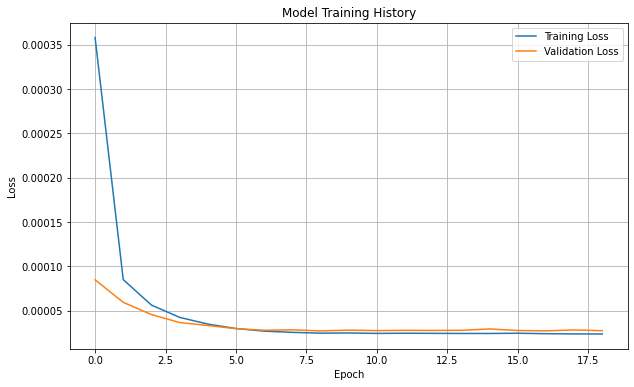

In [18]:
# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
y_pred_scaled = model.predict(X_test)

# Inverse-transform predictions
temp_pred = np.zeros((len(y_pred_scaled), 2))
temp_pred[:, 1] = y_pred_scaled[:, 0]
y_pred = scaler.inverse_transform(temp_pred)[:, 1]

temp_true = np.zeros((len(y_test), 2))
temp_true[:, 1] = y_test
y_true = scaler.inverse_transform(temp_true)[:, 1]

328/328 [==============================] - 12s 16ms/step


In [20]:
def plot_predictions_with_error(true_data, predicted_data, rainfall_data, title):
    plt.figure(figsize=(14, 6))
    
    true_data_flatten = true_data.flatten()
    predicted_data_flatten = predicted_data.flatten()
    rainfall_flatten = rainfall_data.flatten()
    
    error = true_data_flatten - predicted_data_flatten
    residuals_std = np.std(error)
    
    # --- Left subplot: water level + inverted rainfall ---
    ax1 = plt.subplot(1, 2, 1)
    
    # Plot true and predicted water level on primary y-axis
    line1, = ax1.plot(true_data_flatten, label='True Water Level', color='#1f77b4', linewidth=2)
    line2, = ax1.plot(predicted_data_flatten, label='Predicted Water Level', color='#ff7f0e', alpha=0.7, linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Water Level')
    ax1.set_title(title)
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # Create secondary y-axis for rainfall
    ax2 = ax1.twinx()
    line3, = ax2.plot(-rainfall_flatten, label='Inverted Rainfall', color='tab:blue', alpha=0.5)
    ax2.set_ylabel('Rainfall (inverted)')
    
    # Combine legends from ax1 and ax2 into one legend box on ax1
    lines = [line1, line2, line3]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0, 0.9))
    
    # --- Second subplot: residuals ---
    ax3 = plt.subplot(1, 2, 2)
    ax3.scatter(predicted_data_flatten, error, alpha=0.5, label='Residuals')
    ax3.axhline(0, color='red', linestyle='--', label='Zero Error')
    ax3.set_xlabel('Predicted Water Level')
    ax3.set_ylabel('Residuals (True - Predicted)')
    ax3.set_title(f'Residual Plot (Std: {residuals_std:.3f})')
    ax3.legend(loc='upper right')
    ax3.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [21]:
train_pred = model.predict(X_train)
validation_pred = model.predict(X_val)
test_pred = model.predict(X_test)

328/328 [==============================] - 5s 15ms/step


In [22]:
rainfall_train = x[:len(y_train)]
rainfall_val = x[len(y_train):len(y_train) + len(y_val)]
rainfall_test = x[len(y_train) + len(y_val):len(y_train) + len(y_val) + len(y_test)]

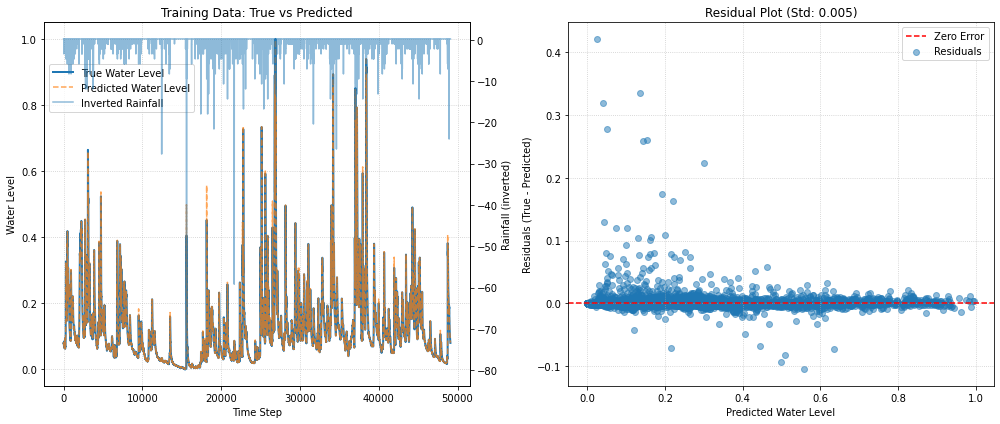

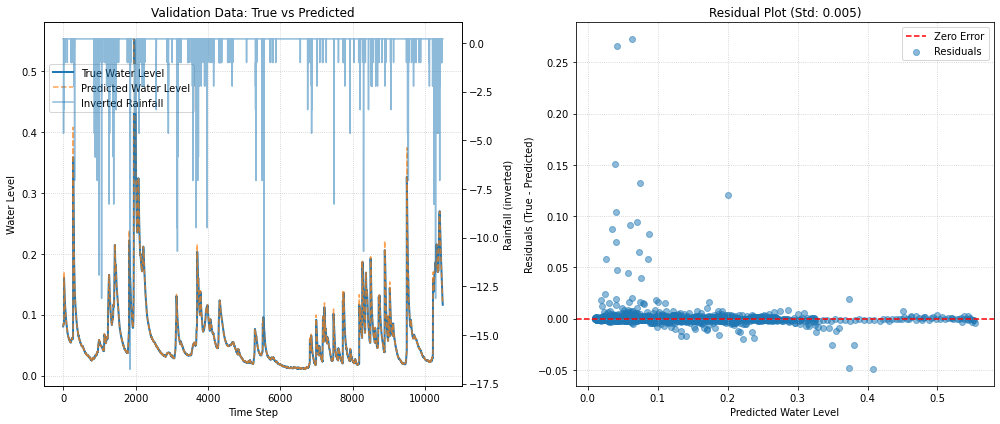

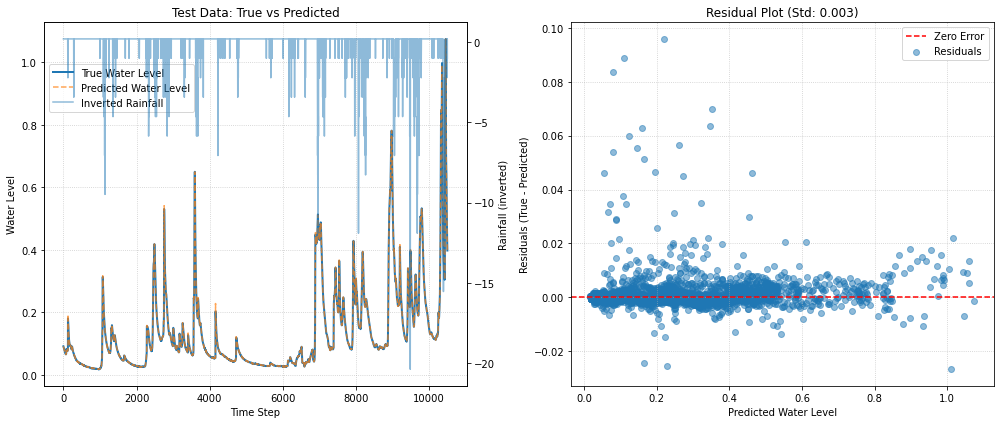

In [23]:
plot_predictions_with_error(y_train, train_pred, rainfall_train, 'Training Data: True vs Predicted')
plot_predictions_with_error(y_val, validation_pred, rainfall_val, 'Validation Data: True vs Predicted')
plot_predictions_with_error(y_test, test_pred, rainfall_test, 'Test Data: True vs Predicted')

In [24]:
# Compute fit stats
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

R²: 0.999
RMSE: 0.007
MAE: 0.002


# Univariate
Input(X): rainfall <br>
Output(Y): water level

In [25]:
scaler_rain = MinMaxScaler()
rain_scaled = scaler_rain.fit_transform(merged[['Rainfall']])  # only rainfall

# target (water level) in original scale or scaled separately
scaler_level = MinMaxScaler()
level_scaled = scaler_level.fit_transform(merged[['WaterLevel']])

# Combine into one array with rainfall as input and water level as output
# Handle separately in create_sequences
rain_scaled = rain_scaled.reshape(-1)    # flatten to 1D
level_scaled = level_scaled.reshape(-1)  # flatten to 1D

In [26]:
# Train/Validation/Test split
train_size = int(len(rain_scaled) * 0.7)
val_size   = int(len(rain_scaled) * 0.15)
test_size  = len(rain_scaled) - train_size - val_size

rain_train = rain_scaled[:train_size]
level_train = level_scaled[:train_size]

rain_val = rain_scaled[train_size:train_size+val_size]
level_val = level_scaled[train_size:train_size+val_size]

rain_test = rain_scaled[train_size+val_size:]
level_test = level_scaled[train_size+val_size:]

In [27]:
# Create sequences
def create_sequences_univariate(input_series, target_series, past_steps=32, forecast_horizon=1):
    X, y = [], []
    for i in range(len(input_series) - past_steps - forecast_horizon + 1):
        X.append(input_series[i : i + past_steps])  # past rainfall only
        y.append(target_series[i + past_steps : i + past_steps + forecast_horizon][-1])  # future water level
    return np.array(X), np.array(y)

past_steps = 32  # based on lag analysis (≈8 hours)
forecast_horizon = 1

X_train, y_train = create_sequences_univariate(rain_train, level_train, past_steps, forecast_horizon)
X_val, y_val = create_sequences_univariate(rain_val, level_val, past_steps, forecast_horizon)
X_test, y_test = create_sequences_univariate(rain_test, level_test, past_steps, forecast_horizon)

# Reshape X for LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (49091, 32, 1) (49091,)
Val: (10494, 32, 1) (10494,)
Test: (10495, 32, 1) (10495,)


In [28]:
model_uni = Sequential()
model_uni.add(LSTM(64, input_shape=(past_steps, 1)))  # 1 feature now
model_uni.add(Dense(1))
model_uni.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=10,           # stop if no improvement for 10 epochs
    restore_best_weights=True
)

history_uni = model_uni.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
768/768 [==============================] - 61s 56ms/step - loss: 0.0079 - val_loss: 0.0052
Epoch 2/200
768/768 [==============================] - 36s 47ms/step - loss: 0.0072 - val_loss: 0.0047
Epoch 3/200
768/768 [==============================] - 44s 58ms/step - loss: 0.0072 - val_loss: 0.0040
Epoch 4/200
768/768 [==============================] - 44s 57ms/step - loss: 0.0072 - val_loss: 0.0058
Epoch 5/200
768/768 [==============================] - 44s 57ms/step - loss: 0.0070 - val_loss: 0.0045
Epoch 6/200
768/768 [==============================] - 44s 58ms/step - loss: 0.0071 - val_loss: 0.0072
Epoch 7/200
768/768 [==============================] - 44s 57ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 8/200
768/768 [==============================] - 43s 56ms/step - loss: 0.0068 - val_loss: 0.0045
Epoch 9/200
768/768 [==============================] - 46s 61ms/step - loss: 0.0067 - val_loss: 0.0070
Epoch 10/200
768/768 [==============================] - 42s 55ms/step - l

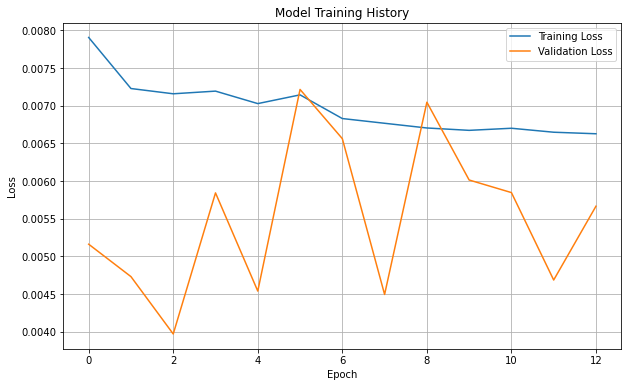

In [34]:
# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_uni.history['loss'], label='Training Loss')
plt.plot(history_uni.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
y_pred_scaled = model_uni.predict(X_test)

# inverse-transform predictions
y_pred = scaler_level.inverse_transform(y_pred_scaled)
y_true = scaler_level.inverse_transform(y_test.reshape(-1,1))

328/328 [==============================] - 10s 16ms/step


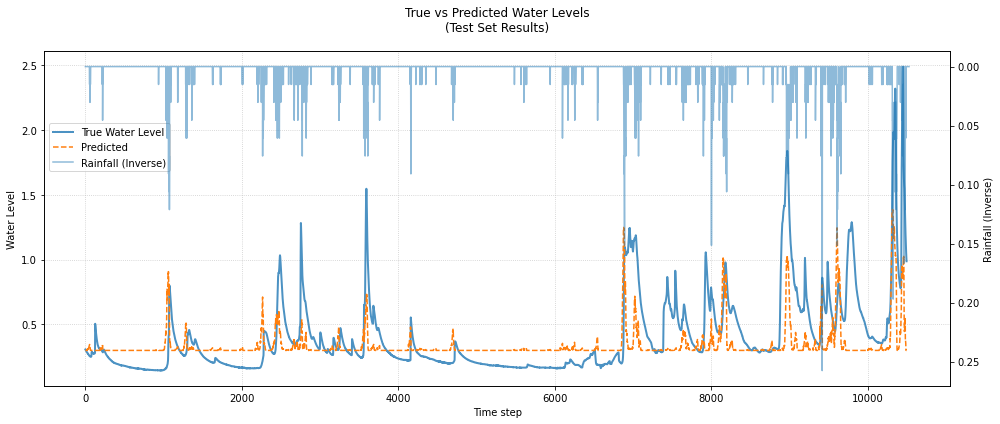

In [32]:
# Inverse-transform predictions and true values
y_pred = scaler_level.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_level.inverse_transform(y_test.reshape(-1, 1)).flatten()

rain_test_reshaped = rain_test.reshape(-1, 1)

# Plot settings
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(y_true, label='True Water Level', color='#1f77b4', linewidth=2, alpha=0.8)
ax1.plot(y_pred, label='Predicted', color='#ff7f0e', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Time step')
ax1.set_ylabel('Water Level')
ax1.grid(True, linestyle=':', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(rain_test_reshaped, label='Rainfall (Inverse)', color='tab:blue', alpha=0.5)
ax2.set_ylabel('Rainfall (Inverse)')
ax2.invert_yaxis()  # invert y-axis for rainfall

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=10, loc='upper left', bbox_to_anchor=(0, 0.8))

plt.title('True vs Predicted Water Levels\n(Test Set Results)', pad=20)
plt.tight_layout()

In [31]:
# Compute fit stats
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

R²: 0.264
RMSE: 0.264
MAE: 0.172
